## 0. Setup

In [12]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RESULTS_PATH     = '../outputs/results/experiment_results_merged.parquet'
HIT_RATES_PATH   = '../outputs/results/product_hit_rates_merged.parquet'
GRAPH_DIR        = '../outputs/graphs'
ALPHA_SWEEP_BASE = '../outputs/results/alpha_sweep'
PLOTS_DIR        = '../outputs/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

METHOD_LABELS   = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER    = ['popularity', 'local_agg', 'ppr']
METHOD_COLORS   = {'popularity': 'tab:gray', 'local_agg': 'tab:orange', 'ppr': 'tab:blue'}
N_OBS_FRACTIONS = [0.25, 0.5, 0.75]
FRAC_LABELS     = {0.25: '25%', 0.5: '50%', 0.75: '75%'}
K_VALUES        = [5, 10, 20]
ALPHA_VALUES    = [0.30, 0.50, 0.70, 0.85]

## 1. Carregamento dos Dados

In [13]:
results   = pd.read_parquet(RESULTS_PATH)
hit_rates = pd.read_parquet(HIT_RATES_PATH)

from src.graph_builder import load_graph
G = load_graph(GRAPH_DIR)
graph_products = set(G.nodes())

test_df = pd.read_parquet('../data/processed/test.parquet', columns=['basket_id', 'product_idx'])
all_test_products = set(test_df['product_idx'].unique())
GRAPH_COV = len(all_test_products & graph_products) / len(all_test_products)

print(f'Resultados:   {len(results):,} linhas')
print(f'Grafo:        {G.number_of_nodes():,} nós, {G.number_of_edges():,} arestas')
print(f'Cobertura do grafo: {GRAPH_COV:.3f} ({100*GRAPH_COV:.1f}%)')

Resultados:   9,013,680 linhas
Grafo:        39,180 nós, 6,205,788 arestas
Cobertura do grafo: 0.708 (70.8%)


## 2. Preparação dos Dados

In [14]:
per_basket_all = (
    results
    .groupby(['basket_id', 'n_obs', 'method', 'k'])[['precision', 'recall']]
    .mean()
    .reset_index()
)
denom = per_basket_all['precision'] + per_basket_all['recall']
per_basket_all['f1'] = np.where(
    denom == 0, 0.0,
    2 * per_basket_all['precision'] * per_basket_all['recall'] / denom.replace(0, np.nan),
)

grand = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
)
grand['method_label'] = grand['method'].map(METHOD_LABELS)
grand['n_obs_label']  = grand['n_obs'].map(FRAC_LABELS)

print(f'per_basket_all: {per_basket_all.shape}, grand: {grand.shape}')

per_basket_all: (901368, 7), grand: (27, 8)


In [15]:
sweep_dfs = []
for alpha_dir in sorted(os.listdir(ALPHA_SWEEP_BASE)):
    path = os.path.join(ALPHA_SWEEP_BASE, alpha_dir, 'experiment_results_merged.parquet')
    df = pd.read_parquet(path)
    df['alpha'] = float(alpha_dir.replace('alpha_', '').replace('_', '.'))
    sweep_dfs.append(df)
sweep = pd.concat(sweep_dfs, ignore_index=True)

sweep_pb = (
    sweep.groupby(['basket_id', 'n_obs', 'method', 'k', 'alpha'])[['precision', 'recall']]
    .mean().reset_index()
)
denom_sw = sweep_pb['precision'] + sweep_pb['recall']
sweep_pb['f1'] = np.where(
    denom_sw == 0, 0.0,
    2 * sweep_pb['precision'] * sweep_pb['recall'] / denom_sw.replace(0, np.nan),
)
sweep_agg = (
    sweep_pb.groupby(['n_obs', 'method', 'k', 'alpha'])[['precision', 'recall', 'f1']]
    .mean().round(4).reset_index()
)
print(f'Alpha sweep: {sorted(sweep["alpha"].unique())}')
print(f'sweep_agg shape: {sweep_agg.shape}')

Alpha sweep: [np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.85)]
sweep_agg shape: (108, 7)


In [16]:
print('Calculando PageRank...')
nodes        = list(G.nodes())
in_strength  = dict(G.in_degree(weight='weight'))
out_strength = dict(G.out_degree(weight='weight'))
pagerank     = nx.pagerank(G, alpha=0.85, weight='weight', max_iter=200)

centrality_df = pd.DataFrame({
    'product_idx':  nodes,
    'in_strength':  [in_strength[n]  for n in nodes],
    'out_strength': [out_strength[n] for n in nodes],
    'pagerank':     [pagerank[n]     for n in nodes],
})
CENTRALITY_METRICS = ['in_strength', 'out_strength', 'pagerank']
metric_labels = {
    'in_strength':  'In-Strength',
    'out_strength': 'Out-Strength',
    'pagerank':     'PageRank',
}
print(f'Centralidade calculada para {len(nodes):,} nós')

corr_rows = []
for k_val in K_VALUES:
    hr_sub = hit_rates[hit_rates['k'] == k_val]
    for method in METHOD_ORDER:
        hr_method = hr_sub[hr_sub['method'] == method][['product_idx', 'hit_rate']]
        merged = centrality_df.merge(hr_method, on='product_idx')
        for metric in CENTRALITY_METRICS:
            rho, pval = spearmanr(merged[metric], merged['hit_rate'])
            corr_rows.append({
                'k': k_val,
                'method': METHOD_LABELS[method],
                'metric': metric,
                'spearman_rho': round(rho, 4),
                'p_value': round(pval, 6),
            })
corr_df = pd.DataFrame(corr_rows)
print('Spearman \u03c1 (k=10):')
display(
    corr_df[corr_df['k'] == 10]
    .pivot_table(index='metric', columns='method', values='spearman_rho')
    [['Popularity', 'LocalAgg', 'PPR']]
    .reindex(CENTRALITY_METRICS)
    .round(4)
)

Calculando PageRank...
Centralidade calculada para 39,180 nós
Spearman ρ (k=10):


method,Popularity,LocalAgg,PPR
metric,,,
in_strength,0.0424,0.4466,0.2430
out_strength,0.0357,0.3222,0.1087
pagerank,0.0425,0.4144,0.2245


## Precision, Recall e F1 por Método

Precision, Recall e F1@k por método e fração de itens observados (barras agrupadas).
Cada métrica numa figura separada; cada subplot corresponde a um valor de k.

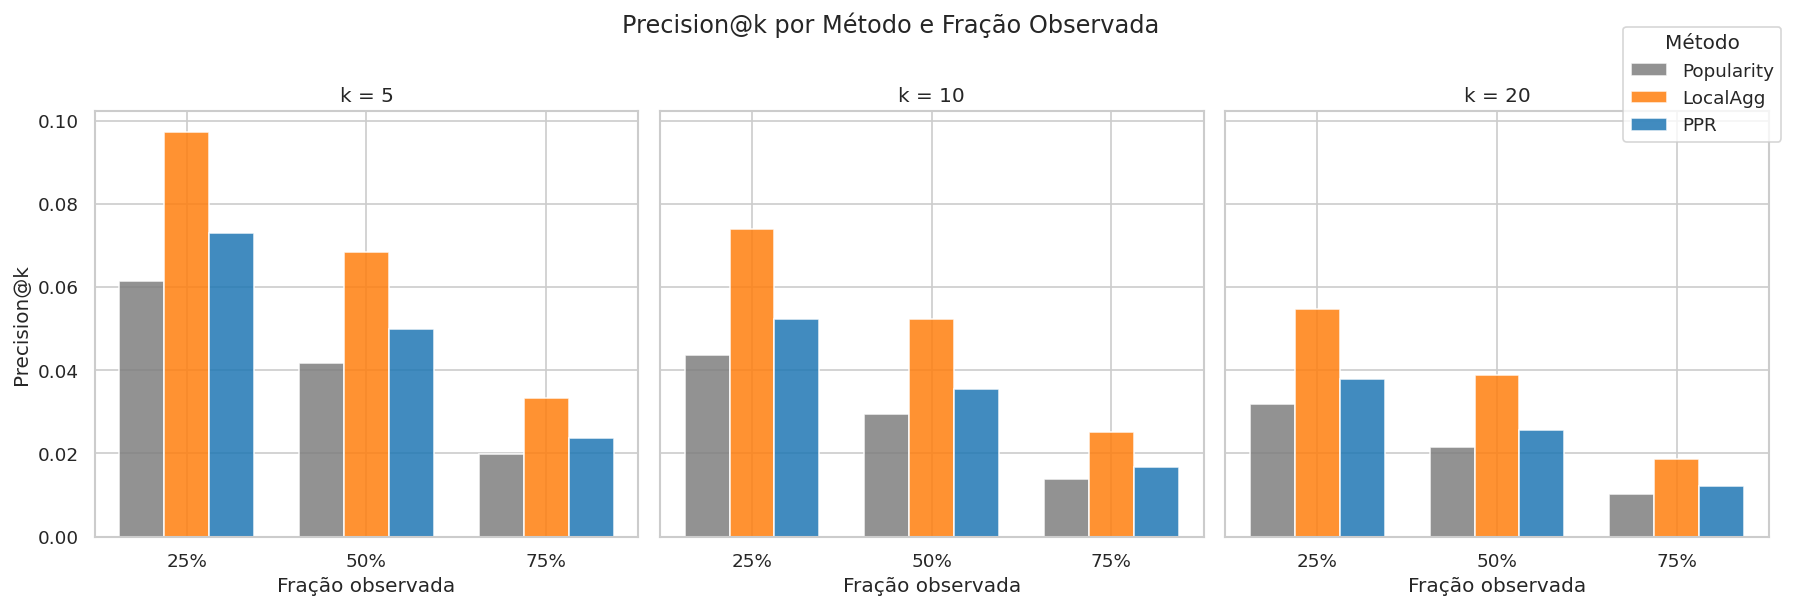

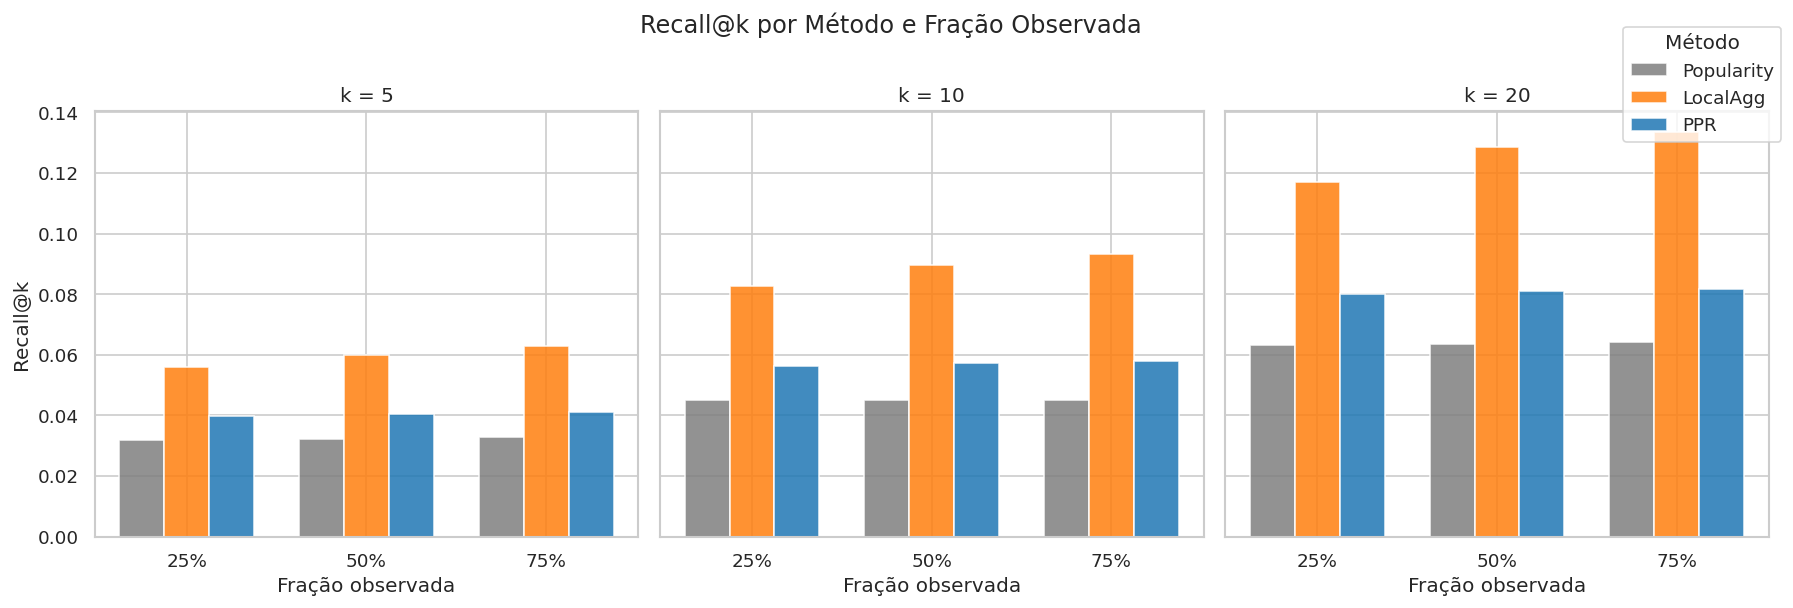

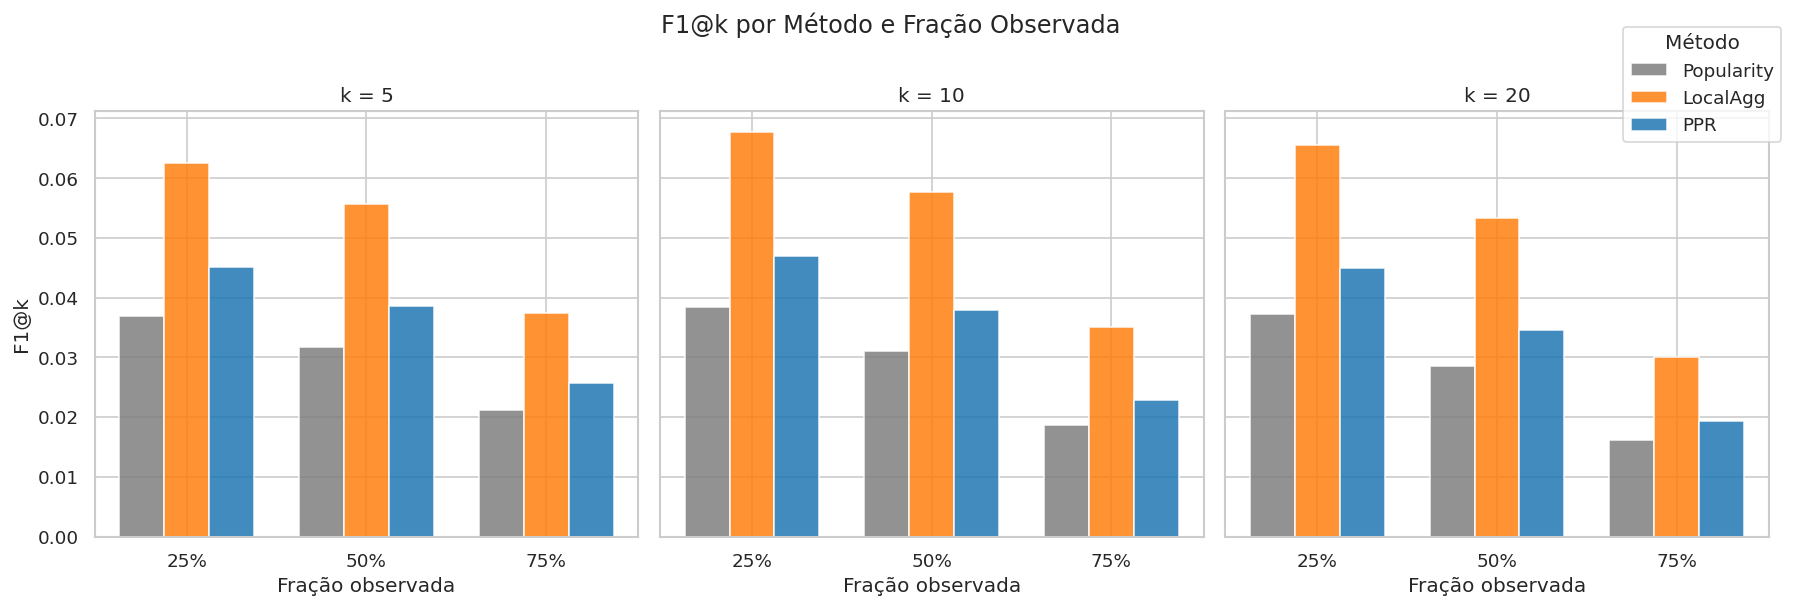

In [17]:
METRICS = [('precision', 'Precision@k'), ('recall', 'Recall@k'), ('f1', 'F1@k')]

x = np.arange(len(N_OBS_FRACTIONS))
width = 0.25

# Criar uma figura separada por métrica (Precision, Recall, F1). Cada figura tem um subplot por valor de k.
for metric, metric_label in METRICS:
    fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 5), sharey=True)
    axes = np.atleast_1d(axes)
    for col, k_val in enumerate(K_VALUES):
        ax = axes[col]
        sub = grand[grand['k'] == k_val].copy()
        sub['n_obs_label'] = pd.Categorical(sub['n_obs_label'], [FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
        pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
        pivot = pivot[[METHOD_LABELS[m] for m in METHOD_ORDER]]
        for i, method in enumerate(METHOD_ORDER):
            ax.bar(
                x + (i - 1) * width, pivot[METHOD_LABELS[method]],
                width=width, label=METHOD_LABELS[method],
                color=METHOD_COLORS[method], alpha=0.85,
            )
        ax.set_xticks(x)
        ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
        ax.set_xlabel('Fração observada')
        if col == 0:
            ax.set_ylabel(metric_label)
        ax.set_title(f'k = {k_val}')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Método', loc='upper right', bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f'{metric_label} por Método e Fração Observada', y=1.01)
    plt.tight_layout()
    fig.savefig(os.path.join(PLOTS_DIR, f'exp_{metric}_vs_n_obs.png'), bbox_inches='tight')
    plt.show()

## PPR Recall@k vs α

Recall@k do PPR em função do parâmetro de difusão α ∈ {0,30; 0,50; 0,70; 0,85},
com LocalAgg e Popularity como referências fixas (n_obs = 50%).

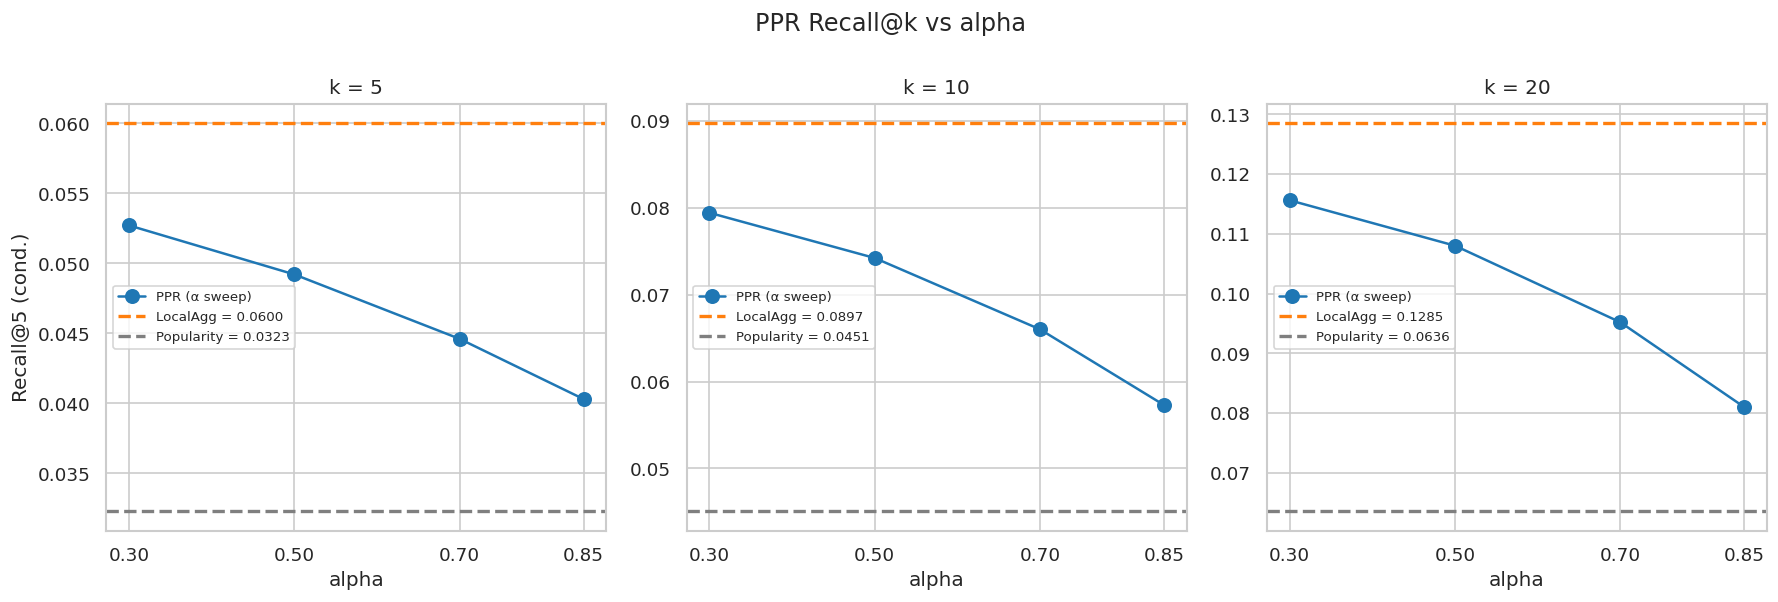

In [24]:
ref_n_obs = 0.5
ref_alpha = 0.85

ppr_curve = sweep_agg[(sweep_agg['method'] == 'ppr') & (sweep_agg['n_obs'] == ref_n_obs)]
ref_la    = sweep_agg[(sweep_agg['method'] == 'local_agg')  & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]
ref_pop   = sweep_agg[(sweep_agg['method'] == 'popularity') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = ppr_curve[ppr_curve['k'] == k_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['recall'], marker='o', markersize=8, color='tab:blue', label='PPR (α sweep)')
    la_val  = ref_la[ref_la['k'] == k_val]['recall'].values[0]
    pop_val = ref_pop[ref_pop['k'] == k_val]['recall'].values[0]
    ax.axhline(la_val,  color='tab:orange', linestyle='--', linewidth=2, label=f'LocalAgg = {la_val:.4f}')
    ax.axhline(pop_val, color='tab:gray',   linestyle='--',  linewidth=2, label=f'Popularity = {pop_val:.4f}')
    ax.set_xlabel('alpha')
    ax.set_ylabel(f'Recall@{k_val} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    ax.set_xticks(ALPHA_VALUES)
    ax.legend(fontsize=8)
fig.suptitle(f'PPR Recall@k vs alpha', y=1)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, 'exp_ppr_recall_vs_alpha.png'), bbox_inches='tight')
plt.show()

## ΔRecall@k (LocalAgg − PPR) por α

Mesmo gap do gráfico anterior, com um subplot por fração observada e linhas separadas
por k. Inclui tabela numérica ao final.

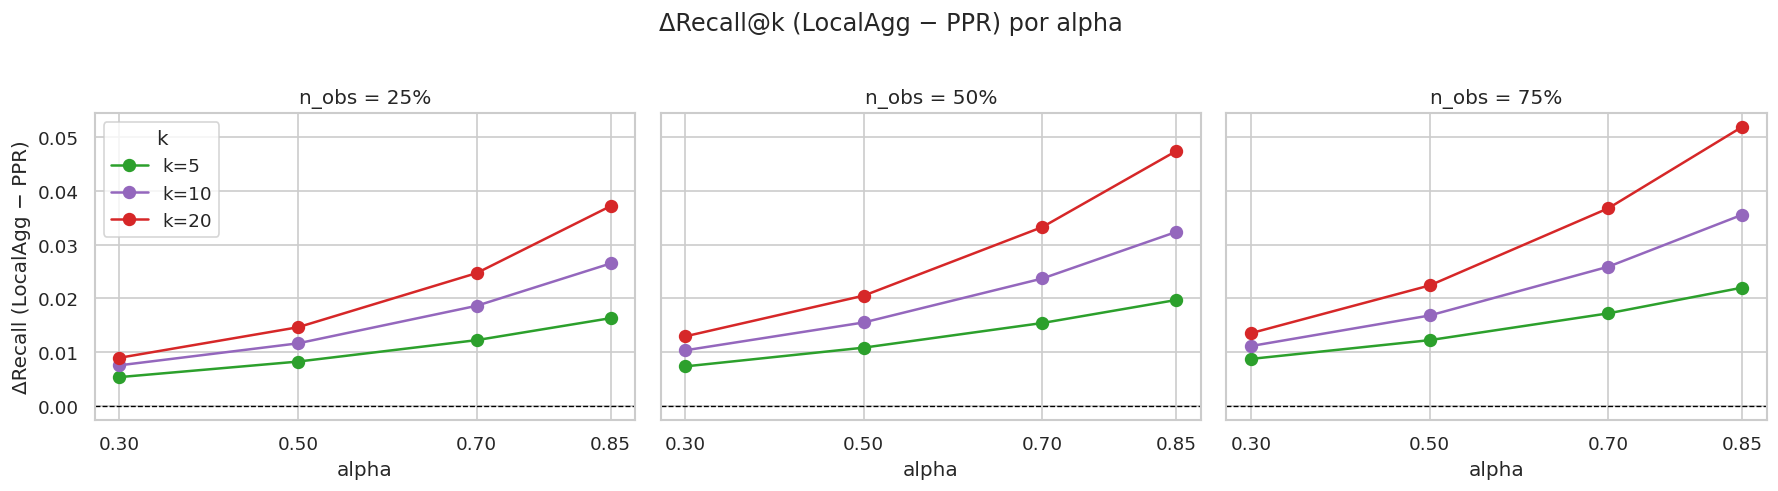


Tabela: ΔRecall (LocalAgg − PPR) por k × alpha

n_obs = 25%


k,5,10,20
alpha,,,
0.30,0.0053,0.0075,0.0089
0.50,0.0082,0.0116,0.0146
0.70,0.0122,0.0186,0.0247
0.85,0.0163,0.0265,0.0372



n_obs = 50%


k,5,10,20
alpha,,,
0.30,0.0073,0.0103,0.0129
0.50,0.0108,0.0155,0.0205
0.70,0.0154,0.0237,0.0333
0.85,0.0197,0.0324,0.0475



n_obs = 75%


k,5,10,20
alpha,,,
0.30,0.0087,0.0111,0.0135
0.50,0.0122,0.0168,0.0224
0.70,0.0172,0.0259,0.0368
0.85,0.0220,0.0356,0.0520


In [ ]:
fig, axes = plt.subplots(1, len(N_OBS_FRACTIONS), figsize=(5 * len(N_OBS_FRACTIONS), 4), sharey=True)

for ax, n_obs_val in zip(axes, N_OBS_FRACTIONS):
    la  = sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['n_obs'] == n_obs_val)]
    ppr = sweep_agg[(sweep_agg['method'] == 'ppr')       & (sweep_agg['n_obs'] == n_obs_val)]

    delta = (
        la.set_index(['k', 'alpha'])[['recall']]
        .subtract(ppr.set_index(['k', 'alpha'])[['recall']])
        .rename(columns={'recall': 'delta_recall'})
        .reset_index()
    )

    for k_val, color in zip(K_VALUES, ['tab:green', 'tab:purple', 'tab:red']):
        sub = delta[delta['k'] == k_val].sort_values('alpha')
        ax.plot(sub['alpha'], sub['delta_recall'], marker='o', markersize=7,
                color=color, label=f'k={k_val}')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(ALPHA_VALUES)
    ax.set_xlabel('alpha')
    ax.set_ylabel('ΔRecall (LocalAgg − PPR)' if ax == axes[0] else '')
    ax.set_title(f'n_obs = {FRAC_LABELS[n_obs_val]}')

axes[0].legend(title='k')
fig.suptitle('ΔRecall@k (LocalAgg − PPR) por alpha', y=1)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, 'exp_delta_recall_localagg_ppr.png'), bbox_inches='tight')
plt.show()

print('\nTabela: ΔRecall (LocalAgg − PPR) por k × alpha')
for n_obs_val in N_OBS_FRACTIONS:
    la  = sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['n_obs'] == n_obs_val)]
    ppr = sweep_agg[(sweep_agg['method'] == 'ppr')       & (sweep_agg['n_obs'] == n_obs_val)]
    delta = (
        la.set_index(['k', 'alpha'])[['recall']]
        .subtract(ppr.set_index(['k', 'alpha'])[['recall']])
        .rename(columns={'recall': 'delta_recall'})
        .reset_index()
    )
    print(f'\nn_obs = {FRAC_LABELS[n_obs_val]}')
    display(delta.pivot_table(index='alpha', columns='k', values='delta_recall').round(4))

## True Recall@k vs Fração de Itens Observados

Recall verdadeiro (corrigido pela cobertura do grafo: ×0,708) em função da fração
observada. Compara a reação dos métodos ao aumento de informação disponível.

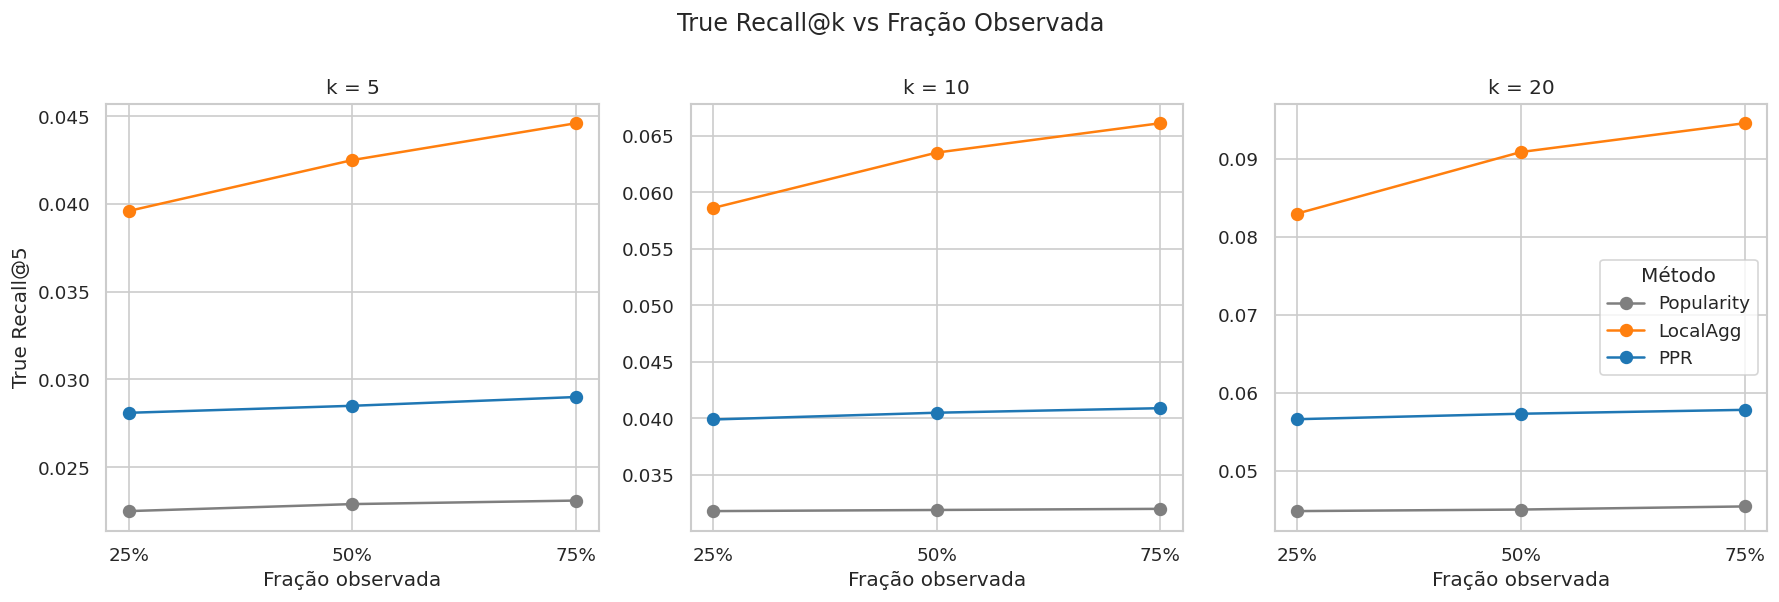

True Recall@k por n_obs × método (k=10):
method       Popularity  LocalAgg     PPR
n_obs_label                              
25%              0.0318    0.0586  0.0399
50%              0.0319    0.0635  0.0405
75%              0.0320    0.0661  0.0409


In [20]:
agg_true = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])['recall']
    .mean()
    .reset_index()
)
agg_true['true_recall'] = (agg_true['recall'] * GRAPH_COV).round(4)
agg_true['n_obs_label'] = agg_true['n_obs'].map(FRAC_LABELS)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = agg_true[agg_true['k'] == k_val]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(grp['n_obs_label'], grp['true_recall'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_xlabel('Fração observada')
    ax.set_ylabel(f'True Recall@{k_val}' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    if ax == axes[-1]:
        ax.legend(title='Método')
fig.suptitle(f'True Recall@k vs Fração Observada', y=1)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, 'exp_true_recall_vs_fraction.png'), bbox_inches='tight')
plt.show()

print('True Recall@k por n_obs × método (k=10):')
print(
    agg_true[agg_true['k']==10]
    .pivot_table(index='n_obs_label', columns='method', values='true_recall')
    .rename(columns=METHOD_LABELS)[['Popularity','LocalAgg','PPR']]
    .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS]).round(4)
)

## Distribuição das Métricas de Centralidade

Histogramas em escala log de In-Strength, Out-Strength e PageRank.
Fornece contexto sobre a distribuição de lei de potência dos nós do grafo.

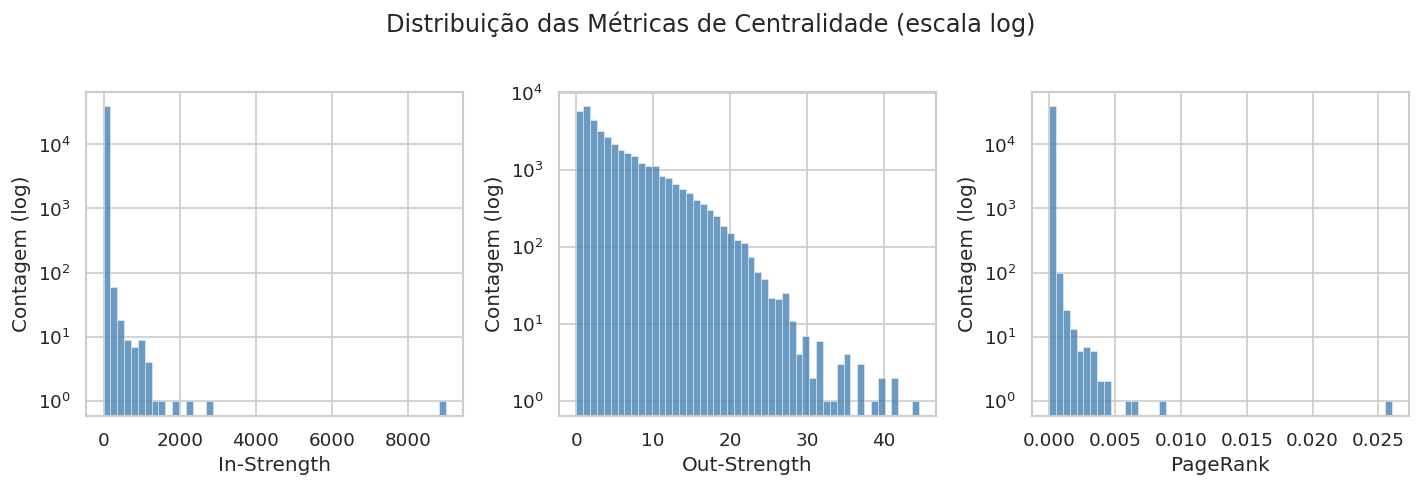

Estatísticas das métricas de centralidade:
  In-Strength      mediana=0.5310  média=5.1565
  Out-Strength     mediana=3.3333  média=5.1565
  PageRank         mediana=0.0000  média=0.0000


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, CENTRALITY_METRICS):
    data = centrality_df[metric]
    ax.hist(data[data > 0], bins=50, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel('Contagem (log)')
fig.suptitle('Distribuição das Métricas de Centralidade (escala log)', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, 'exp_centrality_distribution.png'), bbox_inches='tight')
plt.show()

print('Estatísticas das métricas de centralidade:')
for metric in CENTRALITY_METRICS:
    data = centrality_df[metric]
    print(f'  {metric_labels[metric]:15s}  mediana={data.median():.4f}  média={data.mean():.4f}')

## Correlação de Spearman: Centralidade vs Hit Rate

Spearman ρ entre cada métrica de centralidade (In-Strength, Out-Strength, PageRank)
e a taxa de acerto individual dos produtos, por método e valor de k.

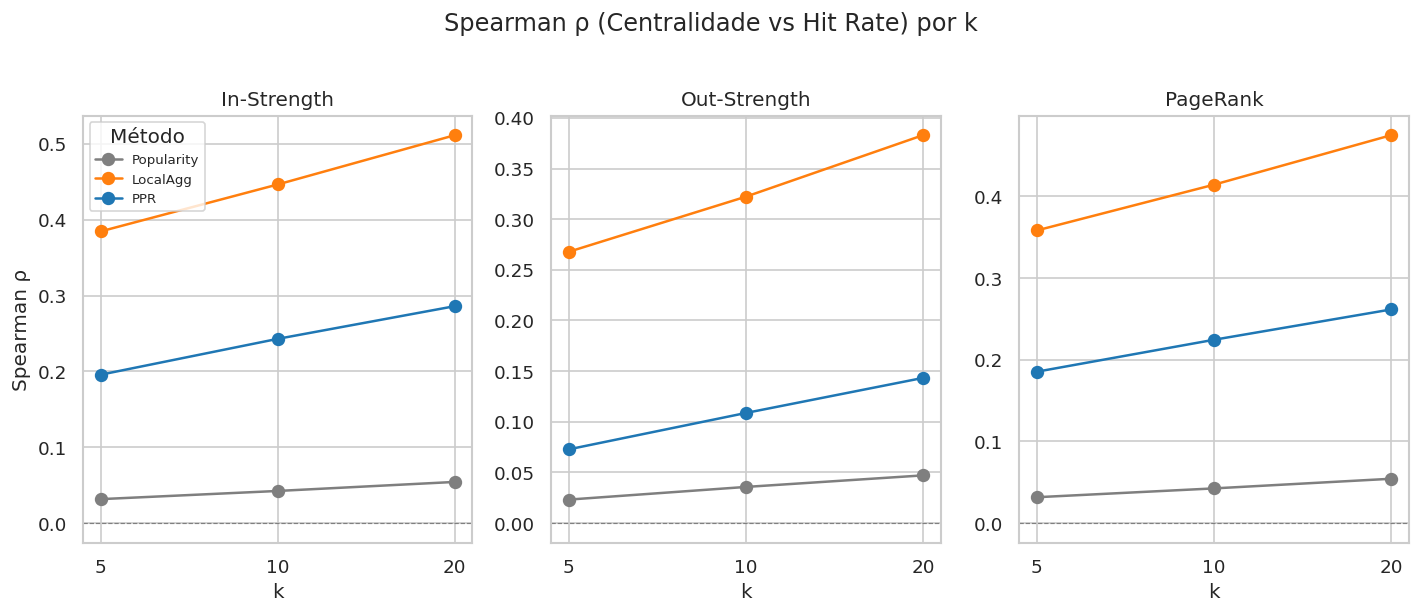

In [22]:
fig, axes = plt.subplots(1, len(CENTRALITY_METRICS), figsize=(4*len(CENTRALITY_METRICS), 5), sharey=False)
for ax, metric in zip(axes, CENTRALITY_METRICS):
    for method in METHOD_ORDER:
        sub = corr_df[(corr_df['method'] == METHOD_LABELS[method]) & (corr_df['metric'] == metric)].sort_values('k')
        ax.plot(sub['k'].astype(str), sub['spearman_rho'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlabel('k')
    ax.set_ylabel('Spearman ρ' if ax == axes[0] else '')
    ax.set_title(metric_labels[metric])
    if ax == axes[0]:
        ax.legend(title='Método', fontsize=8)
fig.suptitle('Spearman ρ (Centralidade vs Hit Rate) por k', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, 'exp_spearman_centrality_hitrate.png'), bbox_inches='tight')
plt.show()